In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('ecommerce_dataset_updated.csv')

## Data Cleaning


In [ ]:
df.shape

(3660, 8)

In [ ]:
df.head()

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024


In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           3660 non-null   object 
 1   product_id        3660 non-null   object 
 2   category          3660 non-null   object 
 3   price_(rs.)       3660 non-null   float64
 4   discount_(%)      3660 non-null   int64  
 5   final_price(rs.)  3660 non-null   float64
 6   payment_method    3660 non-null   object 
 7   purchase_date     3660 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 228.9+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['category'].unique()

array(['sports', 'clothing', 'toys', 'beauty', 'books', 'home_&_kitchen',
       'electronics'], dtype=object)

In [ ]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'], format='%d-%m-%Y')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           3660 non-null   object        
 1   product_id        3660 non-null   object        
 2   category          3660 non-null   object        
 3   price_(rs.)       3660 non-null   float64       
 4   discount_(%)      3660 non-null   int64         
 5   final_price(rs.)  3660 non-null   float64       
 6   payment_method    3660 non-null   object        
 7   purchase_date     3660 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 228.9+ KB


1 - checked duplicate values

2 - checked null values

3 - changed upper caps to lower caps

4 - changed purchase_date from object to datetime

## EDA

Checked for outliers

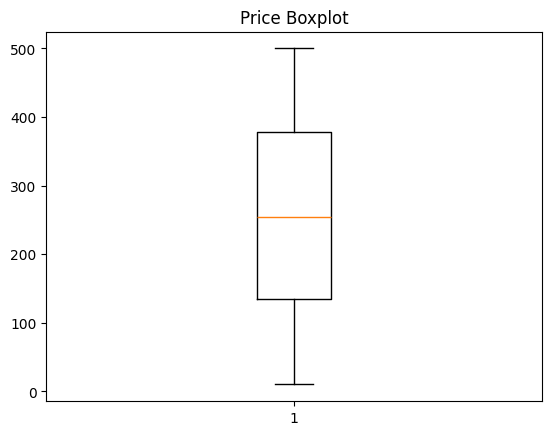

In [ ]:
plt.boxplot(df['price_(rs.)'])
plt.title('Price Boxplot')
plt.show()


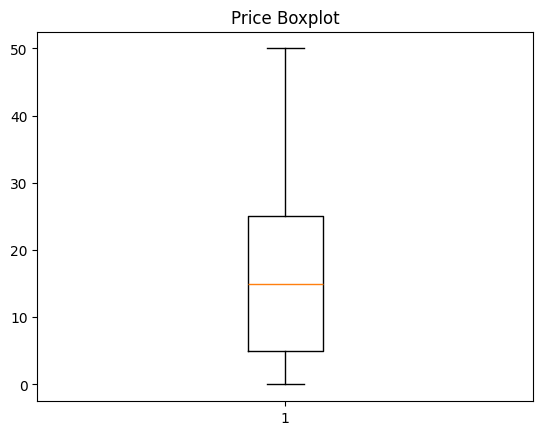

In [ ]:
plt.boxplot(df['discount_(%)'])
plt.title('Price Boxplot')
plt.show()

In [ ]:
df.head(1)

,user_id,product_id,category,price_(rs.),discount_(%),final_price(rs.),payment_method,purchase_date
0,337c166f,f414122f-e,sports,36.53,15,31.05,net_banking,2024-11-12


Q1. What is the total revenue generated?

In [ ]:
df['price_(rs.)'].sum()

np.float64(932570.47)

Q2. Which product category generates the highest revenue?

In [ ]:
df.groupby('category')['price_(rs.)'].sum().sort_values(ascending=False)

,price_(rs.)
category,
clothing,139714.55
books,138371.71
home_&_kitchen,136841.51
sports,134481.99
toys,130207.53
beauty,127633.04
electronics,125320.14


Q3. Which category has the highest number of orders?

In [ ]:
df.groupby('category')['product_id'].count().sort_values(ascending=False)

,product_id
category,
home_&_kitchen,549
books,534
clothing,531
toys,523
sports,520
beauty,505
electronics,498


Q4. What are the monthly sales trends?

purchase_date
2024-01    84202.32
2024-02    84478.21
2024-03    87667.09
2024-04    92252.88
2024-05    86626.21
2024-06    77787.76
2024-07    89238.26
2024-08    88110.88
2024-09    83635.31
2024-10    94501.91
2024-11    64069.64
Freq: M, Name: price_(rs.), dtype: float64


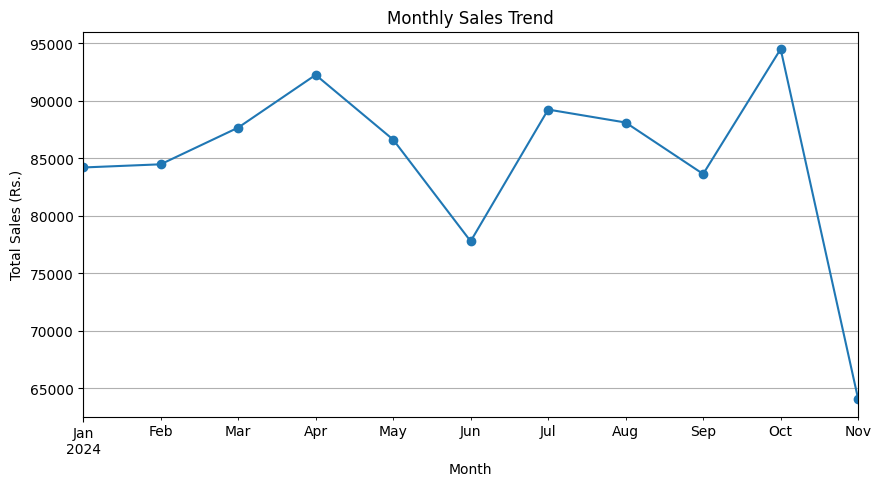

In [ ]:
monthly_sales = df.groupby(df['purchase_date'].dt.to_period('M'))['price_(rs.)'].sum()
print(monthly_sales)

monthly_sales.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (Rs.)')
plt.grid(True)
plt.show()

Q5. Which payment method is used most frequently?

In [ ]:
df.groupby('payment_method')['product_id'].count().sort_values(ascending=False)

,product_id
payment_method,
credit_card,760
upi,757
debit_card,731
net_banking,716
cash_on_delivery,696


Q6. What is the average discount offered across different categories?

In [ ]:
df.groupby('category')['discount_(%)'].mean().sort_values(ascending=False)

,discount_(%)
category,
home_&_kitchen,19.608379
sports,19.326923
electronics,19.267068
books,19.035581
beauty,18.475248
toys,18.126195
clothing,17.919021


Q7. Does a higher discount lead to lower or higher final sales value?

In [ ]:
df.groupby('discount_(%)')['final_price(rs.)'].sum().sort_values(ascending=False)

,final_price(rs.)
discount_(%),
0,122503.80
5,116296.25
10,107994.24
15,104419.15
20,94335.76
30,81332.59
25,75137.57
50,55258.72


Q8. What is the average order value?

In [ ]:
df.groupby('user_id')['final_price(rs.)'].sum().mean()

np.float64(206.90657923497267)

Q9. Which month recorded the highest revenue?

In [ ]:
df.groupby(df['purchase_date'].dt.to_period('M'))['price_(rs.)'].sum().sort_values(ascending=False)

,price_(rs.)
purchase_date,
2024-10,94501.91
2024-04,92252.88
2024-07,89238.26
2024-08,88110.88
2024-03,87667.09
2024-05,86626.21
2024-02,84478.21
2024-01,84202.32
2024-09,83635.31


Q10. What are the top 5 highest-selling products (based on Product_ID)?

In [ ]:
top_products = df.groupby('product_id')['final_price(rs.)'].sum().sort_values(ascending=False).head(5)
print(top_products)

product_id
5a4c2797-7    496.82
2a8fff8b-4    495.02
475d4cf1-c    493.04
e88dc97f-5    492.41
67d7c91c-b    491.70
Name: final_price(rs.), dtype: float64


##Project Insights: E-Commerce Sales Analysis Executive Summary

This analysis evaluated 3,660 sales transactions to understand customer purchasing behavior, revenue performance, and category trends. The dataset covers a range of product categories, payment methods, and discount strategies, providing actionable insights for business optimization.

**Key Findings**

**1. Revenue & Order Performance**

Total Revenue Generated: The platform achieved a total revenue of Rs. 932,570.47.

Top Performing Category (Revenue): The Clothing category generated the highest revenue at Rs. 139,714.55.

Highest Order Volume: Home & Kitchen led the platform in customer engagement with 549 total orders.

Average Order Value: The average purchase value per user is approximately Rs. 206.91.

**2. Temporal Trends**

Peak Sales Month: October 2024 recorded the highest revenue performance (Rs. 94,501.91), indicating strong seasonal demand.

Sales Consistency: While revenue fluctuates monthly, there is consistent demand across all months, with November 2024 experiencing a dip.

**3. Customer Behavior & Operations**

Preferred Payment Method: Credit Card is the most frequently used payment method (760 transactions), followed closely by UPI.

Discount Strategy: The analysis shows that higher discounts do not strictly correlate with higher total sales value. Interestingly, items with 0% discount contributed significantly to the total revenue, suggesting that certain products command high value regardless of promotional pricing.

Top Products: The top 5 highest-revenue-generating products were identified (Product IDs: 5a4c2797-7, 2a8fff8b-4, 475d4cf1-c, e88dc97f-5, 67d7c91c-b), each contributing roughly Rs. 490–497 to the revenue.

**Recommendations**

*   Optimize Inventory for High-Volume Categories: Given that Home & Kitchen has the highest order volume, maintaining stock levels here is critical to sustaining customer flow.

*   Capitalize on Clothing Revenue: Since Clothing drives the most revenue, targeted marketing campaigns or loyalty programs in this category could further boost profitability.

*   Review Promotional Strategy: Since deep discounts are not showing a direct correlation with increased total revenue, consider A/B testing price points or bundling products instead of relying on site-wide discount percentage increases.

*   Payment Infrastructure: Maintain robust support for Credit Card and UPI payments, as these are the preferred channels for the majority of your customer base.









In [ ]:
df.to_csv('cleaned_ecommerce_sales.csv', index=False)